In [23]:
%load_ext autoreload
%autoreload 2

import numpy as np
from numpy import ndarray
import matplotlib.pyplot as plt
%matplotlib inline
from scipy import stats
from typing import Any

from src_decision_making.decision_config import config
from src_decision_making.replacement_agent import ReplacementAgent

plt.rcParams.update(
    {
        "font.family": "serif",
        "axes.labelsize": 22,
        "legend.fontsize": 15,
        "lines.linewidth": 2.5,
        "font.size": 18,
        "text.usetex": True,
        "text.latex.preamble": r"\usepackage{bm} \usepackage{amsmath}",
        "figure.figsize": (10, 6),
    }
)

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


### Benchmark policies

In [24]:
def do_nothing(prog: ndarray, time: int, pol_args: list) -> ndarray:
    """
    Does nothing every time step -> corrective maintenance policy.

    Args:
        prog (N, D): prognostic information
        time: current time/age of the component
        pol_args: list of policy-specific arguments

    Returns:
        acts (N,): array of 0/1 for each component, where 0==DN & 1==PR
    """
    return np.zeros(prog.shape[0])
    
def prob_thres(prog: ndarray, time: int, pol_args: list) -> ndarray:
    """
    Simple probability threshold based policy.

    Args:
        prog (N, D): prognostic information at a certain timestep
        time: current time/age of the component
        pol_args: list of policy-specific arguments

    Returns:
        acts (N,): array of 0/1 for each component, where 0==DN & 1==PR
    """
    a = np.zeros(len(prog)) 

    ub = pol_args[0]
    pf_thres = pol_args[1]
    
    supp = np.arange(prog.shape[1])

    # first find x of support, then interpolate
    cdf = np.cumsum(prog, axis=1) # (N, D)
    pf_preds = np.array(
        [np.interp(x=ub, xp=supp, fp=cdf[k,:]) for k in range(cdf.shape[0])]
    ).squeeze() # (N,)

    #pf_preds = stats.lognorm.cdf(x=ub, s=sigma, scale=np.exp(prog))
    a[pf_preds > pf_thres] = 1
    return a

def age_pol(prog: ndarray, time: int, pol_args: list) -> ndarray:
    """
    Age-based replacement policy: components either fail or are replaced at the
    floored replacement age.

    Args:
        prog (N, D): prognostic information
        time: current time/age of the component
        pol_args: list of policy-specific arguments

    Returns:
        acts (N,): array of 0/1 for each component, where 0==DN & 1==PR
    """
    t_rep = pol_args[0]
    Delta_T = pol_args[1]
    t_rep_floor = (t_rep // Delta_T) * Delta_T

    if time == t_rep_floor:
        a = np.ones(prog.shape[0])
    else:
        a = np.zeros(prog.shape[0]) 
    return a

In [25]:
# create ReplacementAgent object
A = ReplacementAgent(cf=config)

In [26]:
_, _, cr_opt, var_cr_opt = A.opt_pol(tfs=A.trainval_tfs)

_, _, cr_dn, var_cr_dn = A.eval_pol(pol=do_nothing, tfs=A.trainval_tfs, prog=A.trainval_prog)

prob_pol_args = [config["Delta_T"], config["c_p"] / config["c_c"]]
_, _, cr_prob, var_cr_prob = A.eval_pol(pol=prob_thres, tfs=A.trainval_tfs, prog=A.trainval_prog, pol_args=prob_pol_args)

age_pol_args = [A.trainval_tfs.mean(), config["Delta_T"]]
_, _, cr_age, var_cr_age = A.eval_pol(pol=age_pol, tfs=A.trainval_tfs, prog=A.trainval_prog, pol_args=age_pol_args)

Step: 0
Step: 5
Step: 10
Step: 15
Step: 20
Step: 25
Step: 30
Step: 35
Step: 40
Step: 45
Step: 0
Step: 5
Step: 10
Step: 15
Step: 20
Step: 25
Step: 30
Step: 35
Step: 40
Step: 45
Step: 0
Step: 5
Step: 10
Step: 15
Step: 20
Step: 25
Step: 30
Step: 35
Step: 40
Step: 45


In [27]:
def mypol(prog: list, time: int, pol_args: Any) -> ndarray:
    """
    General template for the custom policy.

    Args:
        prog (N, D): list of prognostic information for a batch of N components
        time: the current time passed
        pol_args: list of policy-specific arguments
    
    Returns:
        acts (N,): array of 0/1 for each component, where 0==DN & 1==PR
    """
    acts = np.zeros(len(prog))

    ## TODO: populate now entries of action vector based on chosen heuristic

    return acts

In [ ]:
# TODO: define here the parameters of your policy and evaluate it
my_pol_args = [A.trainval_tfs.mean(), config["Delta_T"]]
_, _, cr_my, var_cr_my = A.eval_pol(pol=mypol, tfs=A.trainval_tfs, prog=A.trainval_prog, pol_args=age_pol_args)

### Visualize results

1.959963984540054 0.0015871288325584835
1.959963984540054 0.015509250960301743
1.959963984540054 0.0474540543588206
1.959963984540054 0.00214650972627024


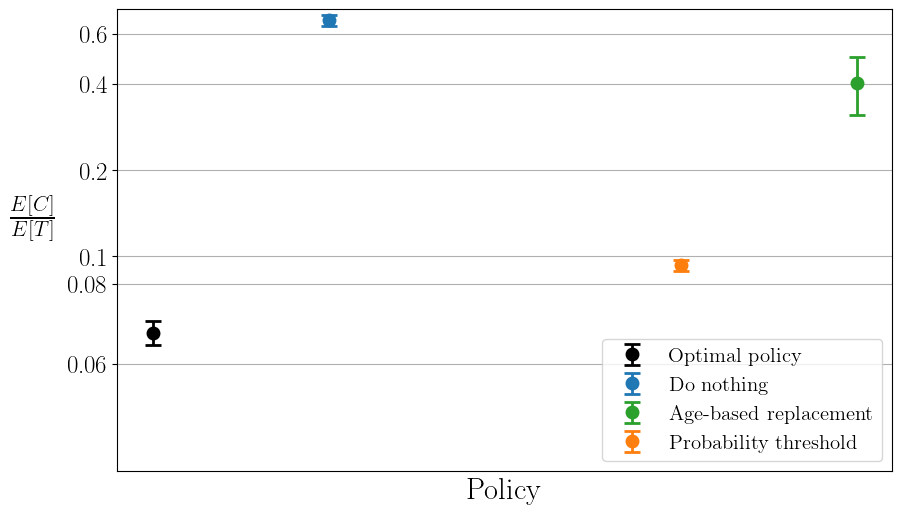

In [30]:
label_dict = {
    "opt_pol": "Optimal policy",
    "do_nothing": "Do nothing",
    "age": "Age-based replacement",
    "prob_thres": "Probability threshold",
    "my_policy": "My policy",
}

color_dict = {
    "opt_pol": "black",
    "do_nothing": "tab:blue",
    "age": "tab:green",
    "prob_thres": "tab:orange",
    "my_policy": "tab:red",
}

pos_dict = {
    "opt_pol": 0,
    "do_nothing": 1,
    "age": 2,
    "prob_thres": 3,
    "age": 4,
    "my_policy": 5,
}

alpha = 0.95 # confidence level
z = stats.norm.ppf(1 - (1 - alpha) / 2)

def plot_pol(key: str, cr: float, var: float):
    err = z * np.sqrt(var)
    print(z, np.sqrt(var))
    plt.errorbar(
        x=pos_dict[key],
        y=[cr],
        yerr=err,
        fmt="o",
        markersize=8,
        #markerfacecolor="white",
        markeredgecolor=color_dict[key],
        markeredgewidth=2,
        color=color_dict[key],
        ecolor=color_dict[key],
        elinewidth=2,
        capsize=6,
        capthick=2,
        label=label_dict[key],
    )

fig = plt.figure(figsize=(10,6))
ax = fig.gca()

if "cr_opt" in globals():
    key = "opt_pol"
    plot_pol(key=key, cr=cr_opt, var=var_cr_opt)

if "cr_dn" in globals():
    key = "do_nothing"
    plot_pol(key=key, cr=cr_dn, var=var_cr_dn)

if "cr_age" in globals():
    key = "age"
    plot_pol(key=key, cr=cr_age, var=var_cr_age)

if "cr_prob" in globals():
    key = "prob_thres"
    plot_pol(key=key, cr=cr_prob, var=var_cr_prob)

if "cr_my" in globals():
    key = "my_policy"
    plot_pol(key=key, cr=cr_my, var=var_cr_my)

plt.xticks([])
plt.xlabel("Policy")
plt.ylabel(r"$\frac{E[C]}{E[T]}$", rotation=0, labelpad=25)
ax.set_yscale("symlog", linthresh=0.08)
yticks = np.array([0.06, 0.08, 0.1, 0.2, 0.4, 0.6])
ax.set_yticks(yticks, yticks)

plt.legend()
plt.grid()
plt.show()
